# 04. Fusion Model

## 0. Setup

In [3]:
import csv
import random
import re
import json
import time
import math
import copy
import traceback
from pathlib import Path
from collections import defaultdict

import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.checkpoint import checkpoint  
from sklearn.metrics import (f1_score, roc_auc_score, mean_absolute_error, mean_squared_error,
                              accuracy_score, recall_score, r2_score, confusion_matrix, roc_curve)
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

MANIFEST = Path('~/Desktop/convscript/Code/Manifest/manifests/master_manifest.csv').expanduser()
ROOT     = Path('~/Desktop/Thesis/TR-6').expanduser() 
GAS_NORM = Path('~/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json').expanduser()
RUNS     = Path('~/Desktop/convscript/runs').expanduser()

DEVICE = (
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)
print(f'Device: {DEVICE}')

FUSION_OUT = RUNS / "04_fusion_model"
FUSION_OUT.mkdir(parents=True, exist_ok=True)


Device: mps


In [4]:
FRUIT_LIST   = ['Banana', 'Carrot', 'Guava', 'Indian_Gooseberry', 'Mango', 'Tomato']
FRUIT_TO_IDX = {f: i for i, f in enumerate(FRUIT_LIST)}
SESSION_TO_IDX = {'morning': 0, 'afternoon': 1, 'evening': 2}
LABEL_TO_IDX   = {'not_spoiled': 0, 'spoiled': 1}
IMAGE_SIZE     = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]
SESSION_HOUR_BUCKETS = {'morning': (5, 11), 'afternoon': (12, 16), 'evening': (16, 19)}
IR_PATTERN   = re.compile(r'(\d{8})_(\d{6})_([\d.]+)C_([\d.]+)C\.jpg$', re.IGNORECASE)
SRGB_PATTERN = re.compile(r'^(\d{8})_(\d{6})[^/]*\.jpg$', re.IGNORECASE)
NUM_FRUITS   = len(FRUIT_TO_IDX)
THRESHOLDS_TO_SWEEP = [t / 100 for t in range(10, 91)]


def safe_float(val, default=0.0):
    try:
        return float(val)
    except Exception:
        return default


def hour_to_session(hour):
    for name, (lo, hi) in SESSION_HOUR_BUCKETS.items():
        if lo <= hour < hi:
            return name
    return 'unknown'


def find_ir_folder(base):
    for name in ['IR_fusion_images', 'IR_Fusion_images', 'ir_fusion_images']:
        p = base / name
        if p.exists():
            return p
    return base / 'IR_fusion_images'


def group_images_by_session(folder, pattern):
    result = defaultdict(lambda: defaultdict(list))
    if not folder.exists():
        return {}
    for f in sorted(folder.iterdir()):
        m = pattern.search(f.name)
        if not m:
            continue
        session = hour_to_session(int(m.group(2)[:2]))
        if session != 'unknown':
            result[m.group(1)][session].append(f)
    return dict(result)


def load_image(path, transform):
    return transform(Image.open(path).convert('RGB'))

In [5]:
def get_rgb_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def get_ir_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


## Data pipeline

In [6]:
class TrimodalDataset(Dataset):
    def __init__(self, manifest_path, root, train=True, modality_dropout_prob=0.3,
                 exclude_flagged=True, split=None, gas_norm_stats_path=None,
                 cache_images=True, shared_pixel_cache=None, gas_only=False):
        self.root = Path(root); self.train = train; self.modality_dropout_prob = modality_dropout_prob
        self.rgb_transform = get_rgb_transform(train); self.ir_transform = get_ir_transform(train)
        self.gas_norm_stats = None
        if gas_norm_stats_path:
            with open(gas_norm_stats_path) as f:
                self.gas_norm_stats = json.load(f)['stats']
            print(f'Gas norm stats loaded from {gas_norm_stats_path}')
        with open(manifest_path, newline='') as f:
            all_rows = list(csv.DictReader(f))
        if exclude_flagged:
            all_rows = [r for r in all_rows if r.get('exclude', '').strip().lower() != 'true']
        if split:
            all_rows = [r for r in all_rows if r.get('split', '').strip().lower() == split.lower()]
        self.samples = []; self._build_samples(all_rows)
        self.gas_only = gas_only; self._image_cache = {}
        if not gas_only:
            self._build_image_index()
        self._pixel_cache = {}
        if not gas_only:
            if shared_pixel_cache is not None:
                self._pixel_cache = shared_pixel_cache
                print(f'  Using shared image cache ({len(self._pixel_cache)} images).', flush=True)
            elif cache_images:
                self._warmup_pixel_cache()
        print(f'TrimodalDataset: {len(self.samples)} sessions '
              f'({"train" if train else "val/test"}, split={split})')

    def _build_samples(self, rows):
        for row in rows:
            fruit = row['fruit']; label = row['label']; date_str = row['actual_date']
            global_day = int(row['corrected_day_index'])
            days_until = safe_float(row.get('days_until_spoilage', ''), default=-1.0)
            for session in ['morning', 'afternoon', 'evening']:
                si = SESSION_TO_IDX[session]
                ir_avail = safe_float(row.get(f'ir_{session}_count', 0)) > 0
                ir_tmin = safe_float(row.get(f'ir_{session}_tmin', ''), 0.0)
                ir_tmax = safe_float(row.get(f'ir_{session}_tmax', ''), 0.0)
                ir_trange = safe_float(row.get(f'ir_{session}_trange', ''), 0.0)
                srgb_avail = safe_float(row.get(f'srgb_{session}_count', 0)) > 0
                gas_avail = row.get(f'methane_{session}_present', '').strip().upper() == 'TRUE'
                mean_ppm = safe_float(row.get(f'methane_{session}_ppm', ''), 0.0)
                std_ppm = safe_float(row.get(f'methane_{session}_std', ''), 0.0)
                left_ppm = safe_float(row.get(f'methane_{session}_left', ''), 0.0)
                right_ppm = safe_float(row.get(f'methane_{session}_right', ''), 0.0)
                if not ir_avail and not srgb_avail and not gas_avail:
                    continue
                self.samples.append({'fruit': fruit, 'label': label, 'actual_date': date_str,
                    'corrected_day_index': global_day, 'session': session, 'session_idx': si,
                    'fruit_idx': FRUIT_TO_IDX.get(fruit, 0), 'label_idx': LABEL_TO_IDX.get(label, 0),
                    'days_until_spoilage': days_until, 'ir_tmin': ir_tmin, 'ir_tmax': ir_tmax,
                    'ir_trange': ir_trange, 'gas_mean': mean_ppm, 'gas_std': std_ppm,
                    'gas_left': left_ppm, 'gas_right': right_ppm, 'gas_asym': abs(left_ppm - right_ppm),
                    'rgb_available': srgb_avail, 'ir_available': ir_avail, 'gas_available': gas_avail})

    def _build_image_index(self):
        label_map = {'not_spoiled': 'Not_spoiled', 'spoiled': 'Spoiled'}
        for fruit in FRUIT_LIST:
            for lk, lf in label_map.items():
                base = self.root / 'Classified' / fruit / lf
                for d, ss in group_images_by_session(base / 'sRGB_images', SRGB_PATTERN).items():
                    for s, ps in ss.items():
                        self._image_cache.setdefault((fruit, lk, d, s), {'rgb': [], 'ir': []})['rgb'] = ps
                for d, ss in group_images_by_session(find_ir_folder(base), IR_PATTERN).items():
                    for s, ps in ss.items():
                        self._image_cache.setdefault((fruit, lk, d, s), {'rgb': [], 'ir': []})['ir'] = ps
        banana_ir = group_images_by_session(find_ir_folder(self.root / 'Normal' / 'Banana'), IR_PATTERN)
        spoiled_dates = {date for (fr, lb, date, _) in self._image_cache if fr == 'Banana' and lb == 'spoiled'}
        for d, ss in banana_ir.items():
            if d in spoiled_dates:
                for s, ps in ss.items():
                    key = ('Banana', 'spoiled', d, s)
                    self._image_cache.setdefault(key, {'rgb': [], 'ir': []})
                    if not self._image_cache[key].get('ir'):
                        self._image_cache[key]['ir'] = ps

    def _load_cached(self, path, transform):
        cached = self._pixel_cache.get(str(path))
        if cached is not None:
            return transform(Image.fromarray(cached.permute(1, 2, 0).numpy()))
        return load_image(path, transform)

    def _warmup_pixel_cache(self):
        all_paths = set()
        for v in self._image_cache.values():
            all_paths.update(v.get('rgb', [])); all_paths.update(v.get('ir', []))
        total = len(all_paths)
        print(f'  Warming up image cache: {total} images...', flush=True)
        for i, path in enumerate(all_paths):
            if str(path) in self._pixel_cache:
                continue
            try:
                img = self.rgb_transform.transforms[0](Image.open(path).convert('RGB'))
                self._pixel_cache[str(path)] = torch.from_numpy(np.array(img)).permute(2, 0, 1)
            except Exception:
                pass
            if (i + 1) % 500 == 0 or (i + 1) == total:
                mb = sum(t.nbytes for t in self._pixel_cache.values()) / (1024 ** 2)
                print(f'  {i + 1}/{total} cached  ({mb:.0f} MB used)', flush=True)
        print(f'  Cache ready. {len(self._pixel_cache)} images in RAM.', flush=True)

    def _normalize_gas(self, fruit, session, mean_ppm, std_ppm, left_ppm, right_ppm):
        if self.gas_norm_stats is None:
            return mean_ppm, std_ppm, left_ppm, right_ppm
        s = self.gas_norm_stats.get(fruit, {}).get(session, {})

        def norm(val, key):
            st = s.get(key, {'mean': 0., 'std': 1.})
            return (val - st['mean']) / st['std']
        return norm(mean_ppm, 'mean_ppm'), norm(std_ppm, 'std_ppm'), norm(left_ppm, 'left_ppm'), norm(right_ppm, 'right_ppm')

    def _apply_dropout(self, rgb_avail, ir_avail, gas_avail):
        if not self.train:
            return rgb_avail, ir_avail, gas_avail
        while True:
            r = rgb_avail and (random.random() > self.modality_dropout_prob)
            i = ir_avail and (random.random() > self.modality_dropout_prob)
            g = gas_avail and (random.random() > self.modality_dropout_prob)
            if r or i or g:
                return r, i, g

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        fruit = s['fruit']; label = s['label']; date_str = s['actual_date']
        session = s['session']; si = s['session_idx']
        rgb_avail, ir_avail, gas_avail = self._apply_dropout(s['rgb_available'], s['ir_available'], s['gas_available'])
        cached = self._image_cache.get((fruit, label, date_str, session), {'rgb': [], 'ir': []})
        if not self.gas_only and rgb_avail and cached['rgb']:
            rgb_tensors = torch.stack([self._load_cached(p, self.rgb_transform) for p in cached['rgb']])
        else:
            rgb_avail = False; rgb_tensors = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
        if not self.gas_only and ir_avail and cached['ir']:
            ir_tensors = torch.stack([self._load_cached(p, self.ir_transform) for p in cached['ir']])
        else:
            ir_avail = False; ir_tensors = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
        ir_scalars = torch.tensor([s['ir_tmin'], s['ir_tmax'], s['ir_trange']], dtype=torch.float32) if ir_avail else torch.zeros(3)
        if gas_avail:
            m, sd, l, r = self._normalize_gas(fruit, session, s['gas_mean'], s['gas_std'], s['gas_left'], s['gas_right'])
            gas = torch.tensor([m, sd, l, r, abs(l - r), float(si) / 2.], dtype=torch.float32)
        else:
            gas = torch.zeros(6)
        return {'rgb_images': rgb_tensors, 'ir_images': ir_tensors, 'ir_scalars': ir_scalars, 'gas': gas,
                'rgb_available': torch.tensor(rgb_avail, dtype=torch.bool),
                'ir_available': torch.tensor(ir_avail, dtype=torch.bool),
                'gas_available': torch.tensor(gas_avail, dtype=torch.bool),
                'fruit_idx': torch.tensor(s['fruit_idx'], dtype=torch.long),
                'session_idx': torch.tensor(si, dtype=torch.long),
                'label': torch.tensor(s['label_idx'], dtype=torch.long),
                'days_until_spoilage': torch.tensor(s['days_until_spoilage'], dtype=torch.float32),
                'fruit': fruit, 'actual_date': date_str, 'corrected_day_index': s['corrected_day_index']}


def trimodal_collate(batch):
    return {'rgb_images': [s['rgb_images'] for s in batch], 'ir_images': [s['ir_images'] for s in batch],
            'ir_scalars': torch.stack([s['ir_scalars'] for s in batch]),
            'gas': torch.stack([s['gas'] for s in batch]),
            'rgb_available': torch.stack([s['rgb_available'] for s in batch]),
            'ir_available': torch.stack([s['ir_available'] for s in batch]),
            'gas_available': torch.stack([s['gas_available'] for s in batch]),
            'fruit_idx': torch.stack([s['fruit_idx'] for s in batch]),
            'session_idx': torch.stack([s['session_idx'] for s in batch]),
            'label': torch.stack([s['label'] for s in batch]),
            'days_until_spoilage': torch.stack([s['days_until_spoilage'] for s in batch]),
            'fruit': [s['fruit'] for s in batch], 'actual_date': [s['actual_date'] for s in batch],
            'corrected_day_index': [s['corrected_day_index'] for s in batch]}

In [7]:
class DayLevelSequenceDataset(Dataset):
    def __init__(self, manifest_path=MANIFEST, root=ROOT, split="train",
                 gas_norm_stats_path=GAS_NORM, shared_pixel_cache=None):
        base = TrimodalDataset(
            manifest_path, root, train=False, modality_dropout_prob=0.0,
            split=split, gas_norm_stats_path=gas_norm_stats_path, cache_images=True,
            shared_pixel_cache=shared_pixel_cache,
        )
        self._pixel_cache = base._pixel_cache
        print(f"DayLevelSequenceDataset ({split}): wrapping {len(base)} sessions")
        day_groups = defaultdict(list)
        for i in range(len(base)):
            item = base[i]
            key = (item["fruit"], int(item["label"].item()), int(item["corrected_day_index"]))
            day_groups[key].append(item)
        day_entries = {}
        for (fruit, label, day_idx), sessions in day_groups.items():
            sessions.sort(key=lambda s: int(s["session_idx"].item()))
            rgb_img, ir_img = None, None
            for s in sessions:
                if rgb_img is None and bool(s["rgb_available"].item()) and len(s["rgb_images"]) > 0:
                    rgb_img = s["rgb_images"][0]
                if ir_img is None and bool(s["ir_available"].item()) and len(s["ir_images"]) > 0:
                    ir_img = s["ir_images"][0]
            gas_vals = [s["gas"] for s in sessions if bool(s["gas_available"].item())]
            gas_avail = len(gas_vals) > 0
            gas_vec = torch.stack(gas_vals).mean(dim=0) if gas_avail else torch.zeros(6)
            day_entries.setdefault((fruit, label), []).append({
                "day_idx": day_idx, "rgb_img": rgb_img, "ir_img": ir_img,
                "gas_vec": gas_vec, "gas_avail": gas_avail,
                "fruit_idx": sessions[0]["fruit_idx"], "label": sessions[0]["label"],
                "days_until": sessions[0]["days_until_spoilage"],
            })
        self.trajectories = []
        for (fruit, label), days in day_entries.items():
            days.sort(key=lambda d: d["day_idx"])
            last_observed_idx = None
            for d in days:
                d["delta"] = 0.0 if last_observed_idx is None else float(d["day_idx"] - last_observed_idx)
                if d["gas_avail"]:
                    last_observed_idx = d["day_idx"]
            self.trajectories.append({"fruit": fruit, "label": label, "days": days})
        n_days_total = sum(len(t["days"]) for t in self.trajectories)
        print(f"  {len(self.trajectories)} trajectories, {n_days_total} total day-entries")

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]["days"]
        T = len(traj)
        blank_rgb = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        blank_ir = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        rgb_seq = torch.stack([d["rgb_img"] if d["rgb_img"] is not None else blank_rgb for d in traj])
        ir_seq = torch.stack([d["ir_img"] if d["ir_img"] is not None else blank_ir for d in traj])
        rgb_avail = torch.tensor([d["rgb_img"] is not None for d in traj], dtype=torch.bool)
        ir_avail = torch.tensor([d["ir_img"] is not None for d in traj], dtype=torch.bool)
        gas_seq = torch.stack([d["gas_vec"] for d in traj])
        gas_mask = torch.tensor([d["gas_avail"] for d in traj], dtype=torch.float32)
        gas_delta = torch.tensor([d["delta"] for d in traj], dtype=torch.float32)
        return {
            "rgb_seq": rgb_seq, "ir_seq": ir_seq, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas_seq, "gas_mask": gas_mask, "gas_delta": gas_delta, "T": T,
            "fruit_idx": traj[0]["fruit_idx"], "label": traj[-1]["label"],
            "days_until": traj[-1]["days_until"],
        }


def day_sequence_collate(batch):
    max_T = max(b["T"] for b in batch)
    B = len(batch)
    rgb = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    ir = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    rgb_avail = torch.zeros(B, max_T, dtype=torch.bool)
    ir_avail = torch.zeros(B, max_T, dtype=torch.bool)
    gas = torch.zeros(B, max_T, 6)
    gas_mask = torch.zeros(B, max_T)
    gas_delta = torch.zeros(B, max_T)
    pad_mask = torch.ones(B, max_T, dtype=torch.bool)
    fruit_idx = torch.zeros(B, dtype=torch.long)
    label = torch.zeros(B, dtype=torch.long)
    days_until = torch.zeros(B, dtype=torch.float32)
    for i, b in enumerate(batch):
        T = b["T"]
        rgb[i, :T] = b["rgb_seq"]; ir[i, :T] = b["ir_seq"]
        rgb_avail[i, :T] = b["rgb_avail"]; ir_avail[i, :T] = b["ir_avail"]
        gas[i, :T] = b["gas_seq"]; gas_mask[i, :T] = b["gas_mask"]; gas_delta[i, :T] = b["gas_delta"]
        pad_mask[i, :T] = False
        fruit_idx[i] = b["fruit_idx"]; label[i] = b["label"]; days_until[i] = b["days_until"]
    return {"rgb_seq": rgb, "ir_seq": ir, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas, "gas_mask": gas_mask, "gas_delta": gas_delta, "pad_mask": pad_mask,
            "fruit_idx": fruit_idx, "label": label, "days_until": days_until}

## TrajectoryDataset

In [8]:
class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]["days"]
        T = len(traj)
        blank_rgb = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        blank_ir = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        rgb_seq = torch.stack([d["rgb_img"] if d["rgb_img"] is not None else blank_rgb for d in traj])
        ir_seq = torch.stack([d["ir_img"] if d["ir_img"] is not None else blank_ir for d in traj])
        rgb_avail = torch.tensor([d["rgb_img"] is not None for d in traj], dtype=torch.bool)
        ir_avail = torch.tensor([d["ir_img"] is not None for d in traj], dtype=torch.bool)
        gas_seq = torch.stack([d["gas_vec"] for d in traj])
        gas_mask = torch.tensor([d["gas_avail"] for d in traj], dtype=torch.float32)
        gas_delta = torch.tensor([d["delta"] for d in traj], dtype=torch.float32)
        return {"rgb_seq": rgb_seq, "ir_seq": ir_seq, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
                "gas_seq": gas_seq, "gas_mask": gas_mask, "gas_delta": gas_delta, "T": T,
                "fruit_idx": traj[0]["fruit_idx"], "label": traj[-1]["label"],
                "days_until": traj[-1]["days_until"]}

## Building blocks

In [9]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(nn.Conv2d(channels, hidden, 1, bias=False), nn.ReLU(inplace=True),
                                  nn.Conv2d(hidden, channels, 1, bias=False))

    def forward(self, x):
        return torch.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out, _ = x.max(dim=1, keepdim=True)
        return torch.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = x * self.channel_attn(x)
        sa = self.spatial_attn(x)
        return x * sa, sa


BACKBONE_FEATURE_DIMS = {"efficientnet_b0": 1280} 


def _infer_feature_dim(backbone, img_size=IMAGE_SIZE):
    backbone.eval()
    with torch.no_grad():
        dummy = torch.zeros(1, 3, img_size, img_size)
        out = backbone(dummy)
    return out.shape[1]


def build_cnn_backbone(name: str):
    if name == "efficientnet_b0":
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        backbone = base.features
        return backbone, BACKBONE_FEATURE_DIMS[name]
    elif name == "convnext_tiny":
        base = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        backbone = base.features
        feat_dim = _infer_feature_dim(backbone)
        BACKBONE_FEATURE_DIMS[name] = feat_dim
        return backbone, feat_dim
    else:
        raise ValueError(f"Unknown backbone: {name} (this notebook only wires up "
                          f"'efficientnet_b0' and 'convnext_tiny')")


class GRUDCell(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, x_mean=None):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        if x_mean is None:
            x_mean = [0.0] * input_dim
        self.register_buffer("x_mean", torch.as_tensor(x_mean, dtype=torch.float32))
        self.W_gamma_x = nn.Linear(1, input_dim)
        self.W_gamma_h = nn.Linear(1, hidden_dim)
        self.gru_cell = nn.GRUCell(input_dim * 2, hidden_dim)

    def forward(self, x_t, m_t, delta_t, x_last, h_prev):
        gamma_x = torch.exp(-torch.clamp(self.W_gamma_x(delta_t), min=0.0))
        x_bar = self.x_mean.unsqueeze(0).expand_as(x_t)
        x_hat = m_t * x_t + (1 - m_t) * (gamma_x * x_last + (1 - gamma_x) * x_bar)
        gamma_h = torch.exp(-torch.clamp(self.W_gamma_h(delta_t), min=0.0))
        h_t = self.gru_cell(torch.cat([x_hat, m_t], dim=-1), gamma_h * h_prev)
        return h_t, x_hat

In [10]:
class VisualEncoderToggle(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", freeze_backbone=True,
                 use_cbam=True, chunk_size=8):
        super().__init__()
        self.use_cbam = use_cbam
        self.backbone_name = backbone_name
        self.chunk_size = chunk_size
        self.backbone, self.feature_dim = build_cnn_backbone(backbone_name)
        if use_cbam:
            self.cbam = CBAM(self.feature_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def unfreeze_last_n_layers(self, n: int):
        self.freeze_backbone()
        for child in list(self.backbone.children())[-n:]:
            for p in child.parameters():
                p.requires_grad = True

    def forward(self, seq: torch.Tensor):
        B, T, C, H, W = seq.shape
        flat = seq.reshape(B * T, C, H, W)
        feats_list = []
        needs_ckpt = (torch.is_grad_enabled()
                      and any(p.requires_grad for p in self.backbone.parameters()))
        for start in range(0, flat.shape[0], self.chunk_size):
            chunk = flat[start:start + self.chunk_size]
            if needs_ckpt:
                feat_map = checkpoint(self.backbone, chunk, use_reentrant=False)
            else:
                feat_map = self.backbone(chunk)
            if self.use_cbam:
                feat_map, _ = self.cbam(feat_map)
            feats_list.append(self.pool(feat_map).flatten(1))
        feats = torch.cat(feats_list, dim=0).view(B, T, -1)
        return feats


class GasGRUDSequenceEncoder(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, x_mean=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = GRUDCell(input_dim, hidden_dim, x_mean)

    def forward(self, gas_seq, gas_mask, gas_delta, pad_mask):
        B, T, D = gas_seq.shape
        device = gas_seq.device
        h = torch.zeros(B, self.hidden_dim, device=device)
        x_last = torch.zeros(B, D, device=device)
        h_seq = []
        for t in range(T):
            x_t = gas_seq[:, t]
            m_t = gas_mask[:, t].unsqueeze(-1).expand(-1, D)
            delta_t = gas_delta[:, t].unsqueeze(-1)
            valid_t = (~pad_mask[:, t]).float().unsqueeze(-1)
            h_new, x_hat = self.cell(x_t, m_t, delta_t, x_last, h)
            h = valid_t * h_new + (1 - valid_t) * h
            x_last = torch.where(m_t.bool(), x_t, x_last)
            h_seq.append(h)
        return torch.stack(h_seq, dim=1)

## Fusion and temporal model

In [11]:
class CrossModalFusion(nn.Module):
    def __init__(self, d_model=64, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads,
                                           dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, rgb_t, ir_t, gas_t, rgb_avail_t, ir_avail_t, gas_avail_t):
        tokens = torch.stack([rgb_t, ir_t, gas_t], dim=1)
        avail = torch.stack([rgb_avail_t, ir_avail_t, gas_avail_t], dim=1)
        key_padding_mask = ~avail
        fully_missing = key_padding_mask.all(dim=1)
        if fully_missing.any():
            key_padding_mask = key_padding_mask.clone()
            key_padding_mask[fully_missing] = False
        attended, attn_w = self.attn(tokens, tokens, tokens, key_padding_mask=key_padding_mask,
                                      need_weights=True, average_attn_weights=True)
        out = self.norm(tokens + attended)
        return out.mean(dim=1), attn_w


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.shape[1]]


class TemporalTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, dim_feedforward=512,
                 dropout=0.1, max_len=100):
        super().__init__()
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
                                            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, z_seq: torch.Tensor, pad_mask: torch.Tensor):
        z_seq = self.pos_enc(z_seq)
        return self.encoder(z_seq, src_key_padding_mask=pad_mask)


def gather_last_valid(H: torch.Tensor, pad_mask: torch.Tensor):
    device = H.device
    lengths = (~pad_mask).sum(dim=1)
    last_idx = (lengths - 1).clamp(min=0)
    B = H.shape[0]
    return H[torch.arange(B, device=device), last_idx], last_idx

In [12]:
class UncertaintyWeightedLoss(nn.Module):
    def __init__(self, n_tasks: int = 3):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.zeros(n_tasks))

    def forward(self, losses: list):
        total = 0.0
        for i, L_i in enumerate(losses):
            precision = torch.exp(-2 * self.log_sigma[i])
            total = total + 0.5 * precision * L_i + self.log_sigma[i]
        return total

    def get_sigmas(self):
        return torch.exp(self.log_sigma).detach().cpu().numpy()

## The trimodal fusion model

In [13]:
class TrimodalFusionModel(nn.Module):
    def __init__(self, rgb_backbone_name="convnext_tiny", ir_backbone_name="efficientnet_b0",
                 d_model=64, gas_hidden=64, num_heads=4, temporal_layers=2,
                 dropout=0.5, cls_dropout=0.5, freeze_visual_backbone=True):
        super().__init__()
        self.d_model = d_model
        self.rgb_backbone_name = rgb_backbone_name
        self.ir_backbone_name = ir_backbone_name

        self.rgb_encoder = VisualEncoderToggle(rgb_backbone_name, freeze_visual_backbone, use_cbam=True)
        self.ir_encoder = VisualEncoderToggle(ir_backbone_name, freeze_visual_backbone, use_cbam=True)
        self.gas_encoder = GasGRUDSequenceEncoder(input_dim=6, hidden_dim=gas_hidden)

        self.rgb_proj = nn.Sequential(nn.Linear(self.rgb_encoder.feature_dim, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.ir_proj = nn.Sequential(nn.Linear(self.ir_encoder.feature_dim, d_model),
                                      nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.gas_proj = nn.Sequential(nn.Linear(gas_hidden, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))

        self.fusion = CrossModalFusion(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.temporal = TemporalTransformer(d_model=d_model, nhead=num_heads,
                                             num_layers=temporal_layers, dropout=dropout)

        self.cls_head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(),
                                       nn.Dropout(cls_dropout), nn.Linear(128, 2))
        self.reg_head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(),
                                       nn.Dropout(cls_dropout), nn.Linear(128, 1), nn.ReLU())
        self.gas_recon_head = nn.Sequential(nn.Linear(d_model * 2, 128), nn.ReLU(),
                                             nn.Dropout(cls_dropout), nn.Linear(128, 6))

    def freeze_visual_backbones(self):
        self.rgb_encoder.freeze_backbone(); self.ir_encoder.freeze_backbone()

    def unfreeze_visual_last_n(self, n: int):
        self.rgb_encoder.unfreeze_last_n_layers(n)
        self.ir_encoder.unfreeze_last_n_layers(n)

    def unfreeze_visual_full(self):
        self.rgb_encoder.unfreeze_backbone()
        self.ir_encoder.unfreeze_backbone()

    def forward(self, batch: dict):
        device = next(self.parameters()).device
        rgb_seq = batch["rgb_seq"].to(device); ir_seq = batch["ir_seq"].to(device)
        rgb_avail = batch["rgb_avail"].to(device); ir_avail = batch["ir_avail"].to(device)
        gas_seq = batch["gas_seq"].to(device); gas_mask = batch["gas_mask"].to(device)
        gas_delta = batch["gas_delta"].to(device); pad_mask = batch["pad_mask"].to(device)
        B, T = rgb_avail.shape

        rgb_feat = self.rgb_encoder(rgb_seq)
        ir_feat = self.ir_encoder(ir_seq)
        gas_feat = self.gas_encoder(gas_seq, gas_mask, gas_delta, pad_mask)

        rgb_proj = self.rgb_proj(rgb_feat) * rgb_avail.unsqueeze(-1).float()
        ir_proj = self.ir_proj(ir_feat) * ir_avail.unsqueeze(-1).float()
        gas_proj = self.gas_proj(gas_feat) * gas_mask.unsqueeze(-1)

        rgb_flat = rgb_proj.reshape(B * T, -1)
        ir_flat = ir_proj.reshape(B * T, -1)
        gas_flat = gas_proj.reshape(B * T, -1)
        rgb_av_flat = rgb_avail.reshape(B * T)
        ir_av_flat = ir_avail.reshape(B * T)
        gas_av_flat = gas_mask.reshape(B * T).bool()
        z_flat, _ = self.fusion(rgb_flat, ir_flat, gas_flat, rgb_av_flat, ir_av_flat, gas_av_flat)
        z_seq = z_flat.reshape(B, T, -1)

        H = self.temporal(z_seq, pad_mask)
        H_T, last_idx = gather_last_valid(H, pad_mask)
        cls_logits = self.cls_head(H_T)
        reg_output = self.reg_head(H_T)

        rgb_last = rgb_proj[torch.arange(B, device=device), last_idx]
        ir_last = ir_proj[torch.arange(B, device=device), last_idx]
        gas_recon = self.gas_recon_head(torch.cat([rgb_last, ir_last], dim=1))

        return {"cls_logits": cls_logits, "reg_output": reg_output, "gas_recon": gas_recon, "last_idx": last_idx}

## Training / evaluation helpers

In [14]:
def build_weighted_sampler(dataset):
    labels = [int(t["label"]) for t in dataset.trajectories]
    n_total = len(labels); n_spoiled = max(sum(labels), 1); n_fresh = max(n_total - sum(labels), 1)
    w_spoiled = n_total / (2 * n_spoiled); w_fresh = n_total / (2 * n_fresh)
    weights = [w_spoiled if l == 1 else w_fresh for l in labels]
    return WeightedRandomSampler(weights=weights, num_samples=n_total, replacement=True)


def calibrate_threshold(scores, labels, thresholds=None):
    if thresholds is None:
        thresholds = THRESHOLDS_TO_SWEEP
    if len(set(labels)) < 2:
        return 0.5, 0.0
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = [1 if s >= t else 0 for s in scores]
        f = f1_score(labels, preds, average="binary", zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


def compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred):
    f1 = f1_score(all_labels, all_preds, average="binary", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)
    recall_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0, labels=[0, 1])
    try:
        auc = roc_auc_score(all_labels, np.array(all_probs)[:, 1])
    except ValueError:
        auc = float("nan")
    mae = mean_absolute_error(all_days_gt, all_days_pred)
    rmse = mean_squared_error(all_days_gt, all_days_pred) ** 0.5
    try:
        r2 = r2_score(all_days_gt, all_days_pred)
    except ValueError:
        r2 = float("nan")
    return {
        "f1": round(f1, 4), "macro_f1": round(macro_f1, 4), "accuracy": round(accuracy, 4),
        "recall_not_spoiled": round(float(recall_per_class[0]), 4),
        "recall_spoiled": round(float(recall_per_class[1]), 4),
        "auc": round(auc, 4), "mae": round(mae, 4), "rmse": round(rmse, 4), "r2": round(r2, 4),
    }


def compute_multitask_loss(out, batch, uncertainty_loss, cfg, device):
    labels = batch["label"].to(device)
    days = batch["days_until"].to(device)
    class_weights = torch.tensor(cfg["cls_class_weights"], device=device)

    cls_loss = nn.CrossEntropyLoss(weight=class_weights)(out["cls_logits"], labels)
    reg_loss = nn.SmoothL1Loss()(out["reg_output"].squeeze(1), days)

    pad_mask = batch["pad_mask"].to(device)
    gas_mask = batch["gas_mask"].to(device)
    gas_seq = batch["gas_seq"].to(device)
    last_idx = out["last_idx"]
    B = labels.shape[0]
    gas_avail_last = gas_mask[torch.arange(B, device=device), last_idx].bool()
    gas_true_last = gas_seq[torch.arange(B, device=device), last_idx]

    if gas_avail_last.any():
        recon_loss = nn.MSELoss()(out["gas_recon"][gas_avail_last], gas_true_last[gas_avail_last])
    else:
        recon_loss = torch.zeros((), device=device)

    total_loss = uncertainty_loss([cls_loss, reg_loss, recon_loss])
    return total_loss, {"cls_loss": cls_loss.item(), "reg_loss": reg_loss.item(), "recon_loss": recon_loss.item()}


def get_cfg():
    return {
        "epochs": 30, "batch_size": 4, "lr": 1e-4, "lr_finetune": 1e-5, "weight_decay": 1e-4,
        "cls_class_weights": [1.0, 2.3], "device": DEVICE,
    }


def collect_probs_labels(model, uncertainty_loss, loader, cfg):
    model.eval(); uncertainty_loss.eval()
    device = cfg["device"]
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            out = model(batch)
            probs = torch.softmax(out["cls_logits"], dim=1).cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            all_days_pred.extend(out["reg_output"].squeeze(1).cpu().numpy().tolist())
    return np.array(all_probs), all_labels, all_days_gt, all_days_pred


def get_calibrated_threshold(model, uncertainty_loss, calib_loader, cfg):
    probs, labels, _, _ = collect_probs_labels(model, uncertainty_loss, calib_loader, cfg)
    threshold, _ = calibrate_threshold(probs[:, 1].tolist(), labels)
    return threshold


def run_epoch(model, uncertainty_loss, loader, optimizer, cfg, train=True, threshold=None):
    model.train() if train else model.eval()
    uncertainty_loss.train() if train else uncertainty_loss.eval()
    device = cfg["device"]
    total_loss = 0.0
    part_sums = {"cls_loss": 0.0, "reg_loss": 0.0, "recon_loss": 0.0}
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            out = model(batch)
            loss, parts = compute_multitask_loss(out, batch, uncertainty_loss, cfg, device)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(list(model.parameters()) + list(uncertainty_loss.parameters()), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            for k in part_sums:
                part_sums[k] += parts[k]
            probs = torch.softmax(out["cls_logits"], dim=1).detach().cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            all_days_pred.extend(out["reg_output"].squeeze(1).detach().cpu().numpy().tolist())

    all_probs_arr = np.array(all_probs)
    if train:
        all_preds = all_probs_arr.argmax(axis=1).tolist()
        threshold_used = 0.5
    else:
        if threshold is None:
            raise ValueError("run_epoch(train=False) requires a threshold -- calibrate one first.")
        threshold_used = threshold
        all_preds = (all_probs_arr[:, 1] >= threshold_used).astype(int).tolist()

    n_batches = max(len(loader), 1)
    metrics = compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred)
    metrics["loss"] = round(total_loss / n_batches, 4)
    metrics["threshold"] = threshold_used
    for k in part_sums:
        metrics[k] = round(part_sums[k] / n_batches, 4)
    return metrics

## Augmentation 

In [15]:
class OfflineAugmentedDayLevelSequenceDataset(Dataset):
    def __init__(self, base_dataset, transform_type="flip_rotation", n_copies=1):
        assert transform_type == "flip_rotation"
        self.base = base_dataset
        self.transform_type = transform_type
        self.n_copies = n_copies

        self.index_map = [] 
        for traj_idx in range(len(base_dataset)):
            self.index_map.append((traj_idx, 0))
            for copy_id in range(1, n_copies + 1):
                self.index_map.append((traj_idx, copy_id))

        self.trajectories = [base_dataset.trajectories[traj_idx] for traj_idx, _ in self.index_map]

        n_orig = len(base_dataset)
        print(f"OfflineAugmentedDayLevelSequenceDataset ({transform_type}, n_copies={n_copies}): "
              f"{n_orig} original trajectories -> {len(self)} total ({n_copies}x duplication)")

    def __len__(self):
        return len(self.index_map)

    def _augment_image(self, img, seed):
        g = torch.Generator().manual_seed(seed)
        out = torch.flip(img, dims=[-1]) 
        angle = (torch.rand(1, generator=g).item() * 30.0) - 15.0 
        out = TF.rotate(out, angle)
        return out

    def __getitem__(self, idx):
        traj_idx, copy_id = self.index_map[idx]
        item = self.base[traj_idx]
        if copy_id == 0:
            return item  

        seed_base = traj_idx * 10_000 + copy_id * 100
        item = dict(item)
        item["rgb_seq"] = torch.stack([
            self._augment_image(item["rgb_seq"][t], seed_base + t)
            for t in range(item["rgb_seq"].shape[0])
        ])
        item["ir_seq"] = torch.stack([
            self._augment_image(item["ir_seq"][t], seed_base + t)
            for t in range(item["ir_seq"].shape[0])
        ])
        return item

## Architecture profiling helper

In [16]:
def estimate_backbone_flops(model, sample_batch, device, n_warmup=3, n_timed=10):
    profile_copy = copy.deepcopy(model).to(device)
    profile_copy.eval()

    n_params = sum(p.numel() for p in profile_copy.parameters())

    flops_g = None
    try:
        from thop import profile as thop_profile
        with torch.no_grad():
            macs, _ = thop_profile(profile_copy, inputs=(sample_batch,), verbose=False)
        flops_g = round(macs * 2 / 1e9, 3) 
    except ImportError:
        print("  [WARN] thop not installed -- FLOPs not measured for this candidate "
              "(pip install thop to enable).")
    except Exception as e:
        print(f"  [WARN] FLOPs profiling failed: {type(e).__name__}: {e}")

    latency_ms = None
    try:
        with torch.no_grad():
            for _ in range(n_warmup):
                profile_copy(sample_batch)
            if device == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()
            for _ in range(n_timed):
                profile_copy(sample_batch)
            if device == "cuda":
                torch.cuda.synchronize()
        latency_ms = round((time.perf_counter() - start) / n_timed * 1000, 1)
    except Exception as e:
        print(f"  [WARN] Latency profiling failed: {type(e).__name__}: {e}")

    del profile_copy
    return {"params_m": round(n_params / 1e6, 2), "flops_g": flops_g, "latency_ms": latency_ms}

## 1. Data 

In [17]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


cfg = get_cfg()
D_MODEL, DROPOUT = 64, 0.5
AUGMENTATION_TRANSFORM = "flip_rotation"
N_COPIES = 1
SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

RGB_BACKBONE_NAME = "convnext_tiny"
IR_BACKBONE_NAME = "efficientnet_b0"
MODEL_LABEL = "ConvNeXt-Tiny RGB + EfficientNet-B0 IR"
RUN_KEY = "model_a_winner"
train_ds = DayLevelSequenceDataset(split="train")
val_ds = DayLevelSequenceDataset(split="val", shared_pixel_cache=train_ds._pixel_cache)
test_ds = DayLevelSequenceDataset(split="test", shared_pixel_cache=train_ds._pixel_cache)
train_loader_calib = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=False,
                                 collate_fn=day_sequence_collate, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False,
                         collate_fn=day_sequence_collate, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg["batch_size"], shuffle=False,
                          collate_fn=day_sequence_collate, num_workers=0)

train_aug_ds = OfflineAugmentedDayLevelSequenceDataset(train_ds, transform_type=AUGMENTATION_TRANSFORM,
                                                        n_copies=N_COPIES)
train_sampler = build_weighted_sampler(train_aug_ds)
train_loader = DataLoader(train_aug_ds, batch_size=cfg["batch_size"], sampler=train_sampler,
                           collate_fn=day_sequence_collate, num_workers=0)
trainval_traj = train_ds.trajectories + val_ds.trajectories
trainval_plain_ds = TrajectoryDataset(trainval_traj)
trainval_loader_calib = DataLoader(trainval_plain_ds, batch_size=cfg["batch_size"], shuffle=False,
                                    collate_fn=day_sequence_collate, num_workers=0)

print(f"train: {len(train_ds.trajectories)} trajectories ({len(train_aug_ds)} incl. augmentation)")
print(f"val:   {len(val_ds.trajectories)} trajectories (held out during training)")
print(f"test:  {len(test_ds.trajectories)} trajectories (untouched until Section 5)")


Gas norm stats loaded from /Users/sjanani2073/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json
  Warming up image cache: 10983 images...
  500/10983 cached  (72 MB used)
  1000/10983 cached  (144 MB used)
  1500/10983 cached  (215 MB used)
  2000/10983 cached  (287 MB used)
  2500/10983 cached  (359 MB used)
  3000/10983 cached  (431 MB used)
  3500/10983 cached  (502 MB used)
  4000/10983 cached  (574 MB used)
  4500/10983 cached  (646 MB used)
  5000/10983 cached  (718 MB used)
  5500/10983 cached  (790 MB used)
  6000/10983 cached  (861 MB used)
  6500/10983 cached  (933 MB used)
  7000/10983 cached  (1005 MB used)
  7500/10983 cached  (1077 MB used)
  8000/10983 cached  (1148 MB used)
  8500/10983 cached  (1220 MB used)
  9000/10983 cached  (1292 MB used)
  9500/10983 cached  (1364 MB used)
  10000/10983 cached  (1436 MB used)
  10500/10983 cached  (1507 MB used)
  10983/10983 cached  (1577 MB used)
  Cache ready. 10983 images in RAM.
TrimodalDataset: 212 sessions (val/

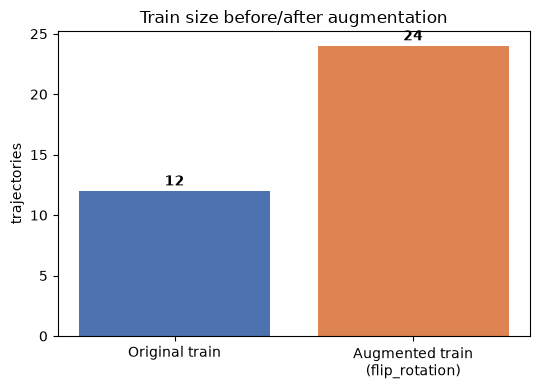

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 4))
sizes = [len(train_ds.trajectories), len(train_aug_ds)]
labels = ["Original train", f"Augmented train\n({AUGMENTATION_TRANSFORM})"]
bars = ax.bar(labels, sizes, color=["#4C72B0", "#DD8452"])
for b, s in zip(bars, sizes):
    ax.annotate(str(s), (b.get_x() + b.get_width() / 2, s), textcoords="offset points",
                xytext=(0, 4), ha="center", fontweight="bold")
ax.set_ylabel("trajectories")
ax.set_title("Train size before/after augmentation")
plt.tight_layout()
plt.show()


## 2. Model definitions

In [19]:
sample_batch = next(iter(test_loader))
set_seed(0)
probe_model = TrimodalFusionModel(
    rgb_backbone_name=RGB_BACKBONE_NAME, ir_backbone_name=IR_BACKBONE_NAME,
    d_model=D_MODEL, dropout=DROPOUT, cls_dropout=DROPOUT, freeze_visual_backbone=True,
).to(cfg["device"])
profile = estimate_backbone_flops(probe_model, sample_batch, cfg["device"])
del probe_model
print(f"[{MODEL_LABEL}]")
print(f"  profile: {profile}")


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2321/1486618883.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


[ConvNeXt-Tiny RGB + EfficientNet-B0 IR]
  profile: {'params_m': 32.47, 'flops_g': 39.026, 'latency_ms': 36.9}


## 3. Training helper

In [20]:
def train_one_run_verbose(run_key, seed, seed_num, n_seeds, loader_train, loader_calib, loader_val, out_dir):
    set_seed(seed)
    run_dir = out_dir / run_key / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    model = TrimodalFusionModel(
        rgb_backbone_name=RGB_BACKBONE_NAME, ir_backbone_name=IR_BACKBONE_NAME,
        d_model=D_MODEL, dropout=DROPOUT, cls_dropout=DROPOUT, freeze_visual_backbone=True,
    ).to(cfg["device"])
    uncertainty_loss = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])

    ir_backbone_ids = {id(p) for p in model.ir_encoder.backbone.parameters()}
    other_params = [p for p in model.parameters() if id(p) not in ir_backbone_ids]
    optimizer = AdamW([
        {"params": other_params, "lr": cfg["lr"]},
        {"params": model.ir_encoder.backbone.parameters(), "lr": cfg["lr_finetune"]},
        {"params": uncertainty_loss.parameters(), "lr": cfg["lr"]},
    ], weight_decay=cfg["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg["epochs"])

    print(f"{'-' * 90}")
    print(f"[{MODEL_LABEL}] seed {seed} ({seed_num}/{n_seeds}) -- {cfg['epochs']} epochs, "
          f"trained on train ({len(loader_train.dataset)} trajectories incl. augmentation), "
          f"validated on held-out val ({len(loader_val.dataset)} trajectories)")
    print(f"{'-' * 90}")

    history = []
    best_val_f1, best_metrics, best_state = -1.0, None, None
    run_start = time.time()
    for epoch in range(1, cfg["epochs"] + 1):
        epoch_start = time.time()
        unfreeze_note = ""
        if epoch == 6:
            model.unfreeze_visual_last_n(1); unfreeze_note = "  [unfreeze last-1]"
        elif epoch == 8:
            model.unfreeze_visual_last_n(2); unfreeze_note = "  [unfreeze last-2]"
        elif epoch == 12:
            model.unfreeze_visual_full(); unfreeze_note = "  [unfreeze full]"

        train_m = run_epoch(model, uncertainty_loss, loader_train, optimizer, cfg, train=True)
        scheduler.step()

        # Threshold calibrated on train (never on val), then applied to score the
        # genuinely held-out val set -- val never contributes a gradient update.
        thr = get_calibrated_threshold(model, uncertainty_loss, loader_calib, cfg)
        val_m = run_epoch(model, uncertainty_loss, loader_val, optimizer, cfg, train=False, threshold=thr)
        epoch_time = time.time() - epoch_start

        is_best = val_m["f1"] > best_val_f1
        if is_best:
            best_val_f1 = val_m["f1"]
            best_metrics = val_m
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        sigmas = uncertainty_loss.get_sigmas()
        history.append({
            "epoch": epoch, "train_loss": train_m["loss"], "train_f1": train_m["f1"],
            "train_auc": train_m["auc"], "train_mae": train_m["mae"],
            "val_f1": val_m["f1"], "val_auc": val_m["auc"], "val_mae": val_m["mae"], "val_threshold": thr,
            "cls_loss": train_m["cls_loss"], "reg_loss": train_m["reg_loss"], "recon_loss": train_m["recon_loss"],
            "sigma_cls": float(sigmas[0]), "sigma_reg": float(sigmas[1]), "sigma_recon": float(sigmas[2]),
            "lr": optimizer.param_groups[0]["lr"], "epoch_time_s": round(epoch_time, 1),
        })

        print(f"  seed {seed} | epoch {epoch:2d}/{cfg['epochs']} | "
              f"train_loss={train_m['loss']:.4f} train_F1={train_m['f1']:.3f} | "
              f"val_F1={val_m['f1']:.3f} val_AUC={val_m['auc']:.3f} val_MAE={val_m['mae']:.2f} "
              f"thr={thr:.2f}{'  *' if is_best else ''} | {epoch_time:.1f}s{unfreeze_note}")

    torch.save(best_state, run_dir / "model_state.pt")
    with open(run_dir / "history.json", "w") as f:
        json.dump(history, f, indent=2, default=str)

    total_time = time.time() - run_start
    print(f"  [{run_key} seed={seed}] DONE in {total_time / 60:.1f} min -- "
          f"BEST val F1={best_metrics['f1']:.4f} AUC={best_metrics['auc']:.4f} "
          f"(threshold={best_metrics['threshold']:.2f})")

    return {"seed": seed, "val_f1": best_metrics["f1"], "val_auc": best_metrics["auc"],
            "threshold": best_metrics["threshold"], "history": history, "total_time_s": round(total_time, 1)}


## 4. Train Model

In [ ]:
print(f"{len(SEEDS)} seeds, {cfg['epochs']} epochs each, trained on train, validated on held-out val")

fusion_results = []
for i, seed in enumerate(SEEDS, start=1):
    try:
        r = train_one_run_verbose(RUN_KEY, seed, i, len(SEEDS),
                                   train_loader, train_loader_calib, val_loader, FUSION_OUT)
        fusion_results.append(r)
    except Exception as e:
        print(f"  [FAILED] {RUN_KEY} seed={seed}: {type(e).__name__}: {e}")
        traceback.print_exc()

if fusion_results:
    f1s = [r["val_f1"] for r in fusion_results]
    print(f"\n{MODEL_LABEL}: {len(f1s)}/{len(SEEDS)} seeds completed. "
          f"mean best-epoch val F1 = {np.mean(f1s):.4f} (std={np.std(f1s):.4f})")


10 seeds, 30 epochs each, trained on train, validated on held-out val


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2321/1486618883.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


------------------------------------------------------------------------------------------
[ConvNeXt-Tiny RGB + EfficientNet-B0 IR] seed 0 (1/10) -- 30 epochs, trained on train (24 trajectories incl. augmentation), validated on held-out val (12 trajectories)
------------------------------------------------------------------------------------------
  seed 0 | epoch  1/30 | train_loss=1.8565 train_F1=0.421 | val_F1=0.364 val_AUC=0.278 val_MAE=2.17 thr=0.41  * | 5.1s
  seed 0 | epoch  2/30 | train_loss=1.5573 train_F1=0.643 | val_F1=0.615 val_AUC=0.472 val_MAE=2.17 thr=0.46  * | 3.4s
  seed 0 | epoch  3/30 | train_loss=1.7543 train_F1=0.571 | val_F1=0.667 val_AUC=0.500 val_MAE=2.17 thr=0.10  * | 4.4s
  seed 0 | epoch  4/30 | train_loss=2.7842 train_F1=0.615 | val_F1=0.667 val_AUC=0.139 val_MAE=2.17 thr=0.10 | 7.0s
  seed 0 | epoch  5/30 | train_loss=2.4701 train_F1=0.480 | val_F1=0.333 val_AUC=0.278 val_MAE=2.17 thr=0.62 | 5.8s
  seed 0 | epoch  6/30 | train_loss=2.1479 train_F1=0.727 | v

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2321/1486618883.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


------------------------------------------------------------------------------------------
[ConvNeXt-Tiny RGB + EfficientNet-B0 IR] seed 1 (2/10) -- 30 epochs, trained on train (24 trajectories incl. augmentation), validated on held-out val (12 trajectories)
------------------------------------------------------------------------------------------
  seed 1 | epoch  1/30 | train_loss=2.0960 train_F1=0.733 | val_F1=0.706 val_AUC=0.722 val_MAE=2.17 thr=0.56  * | 6.0s
  seed 1 | epoch  2/30 | train_loss=2.2146 train_F1=0.571 | val_F1=0.706 val_AUC=0.694 val_MAE=2.17 thr=0.57 | 5.6s
  seed 1 | epoch  3/30 | train_loss=1.8576 train_F1=0.690 | val_F1=0.667 val_AUC=0.583 val_MAE=2.17 thr=0.60 | 4.4s
  seed 1 | epoch  4/30 | train_loss=2.6770 train_F1=0.500 | val_F1=0.667 val_AUC=0.500 val_MAE=2.14 thr=0.54 | 7.6s
  seed 1 | epoch  5/30 | train_loss=2.3941 train_F1=0.518 | val_F1=0.750 val_AUC=0.694 val_MAE=2.15 thr=0.63  * | 6.7s
  seed 1 | epoch  6/30 | train_loss=1.8111 train_F1=0.722 | val_

...

------------------------------------------------------------------------------------------
[ConvNeXt-Tiny RGB + EfficientNet-B0 IR] seed 6 (7/10) -- 30 epochs, trained on train (24 trajectories incl. augmentation), validated on held-out val (12 trajectories)
------------------------------------------------------------------------------------------
  seed 6 | epoch  1/30 | train_loss=1.4874 train_F1=0.757 | val_F1=0.000 val_AUC=0.417 val_MAE=2.15 thr=0.62  * | 5.4s
  seed 6 | epoch  2/30 | train_loss=2.7825 train_F1=0.562 | val_F1=0.000 val_AUC=0.361 val_MAE=2.15 thr=0.62 | 7.0s
  seed 6 | epoch  3/30 | train_loss=2.2339 train_F1=0.483 | val_F1=0.250 val_AUC=0.583 val_MAE=2.16 thr=0.62  * | 5.6s
  seed 6 | epoch  4/30 | train_loss=2.2847 train_F1=0.667 | val_F1=0.462 val_AUC=0.528 val_MAE=2.17 thr=0.57  * | 6.9s
  seed 6 | epoch  5/30 | train_loss=1.6148 train_F1=0.606 | val_F1=0.571 val_AUC=0.444 val_MAE=2.16 thr=0.59  * | 5.2s
  seed 6 | epoch  6/30 | train_loss=1.4562 train_F1=0.545 

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2321/1486618883.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


------------------------------------------------------------------------------------------
[ConvNeXt-Tiny RGB + EfficientNet-B0 IR] seed 7 (8/10) -- 30 epochs, trained on train (24 trajectories incl. augmentation), validated on held-out val (12 trajectories)
------------------------------------------------------------------------------------------
  seed 7 | epoch  1/30 | train_loss=1.3006 train_F1=0.706 | val_F1=0.667 val_AUC=0.333 val_MAE=2.19 thr=0.10  * | 3.7s
  seed 7 | epoch  2/30 | train_loss=1.4780 train_F1=0.789 | val_F1=0.750 val_AUC=0.556 val_MAE=2.16 thr=0.66  * | 5.4s
  seed 7 | epoch  3/30 | train_loss=2.5670 train_F1=0.643 | val_F1=0.667 val_AUC=0.667 val_MAE=2.15 thr=0.66 | 7.0s
  seed 7 | epoch  4/30 | train_loss=1.8568 train_F1=0.645 | val_F1=0.667 val_AUC=0.528 val_MAE=2.17 thr=0.67 | 6.1s
  seed 7 | epoch  5/30 | train_loss=2.1219 train_F1=0.606 | val_F1=0.625 val_AUC=0.639 val_MAE=2.13 thr=0.73 | 5.1s
  seed 7 | epoch  6/30 | train_loss=1.3773 train_F1=0.686 | val_

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2321/1486618883.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


------------------------------------------------------------------------------------------
[ConvNeXt-Tiny RGB + EfficientNet-B0 IR] seed 8 (9/10) -- 30 epochs, trained on train (24 trajectories incl. augmentation), validated on held-out val (12 trajectories)
------------------------------------------------------------------------------------------
  seed 8 | epoch  1/30 | train_loss=2.7018 train_F1=0.455 | val_F1=0.667 val_AUC=0.694 val_MAE=2.14 thr=0.10  * | 8.0s
  seed 8 | epoch  2/30 | train_loss=1.4876 train_F1=0.462 | val_F1=0.625 val_AUC=0.611 val_MAE=2.14 thr=0.45 | 4.9s
  seed 8 | epoch  3/30 | train_loss=1.4757 train_F1=0.533 | val_F1=0.667 val_AUC=0.583 val_MAE=2.17 thr=0.10 | 5.0s
  seed 8 | epoch  4/30 | train_loss=2.0093 train_F1=0.645 | val_F1=0.667 val_AUC=0.611 val_MAE=2.17 thr=0.10 | 6.8s
  seed 8 | epoch  5/30 | train_loss=1.9193 train_F1=0.518 | val_F1=0.667 val_AUC=0.722 val_MAE=2.14 thr=0.10 | 7.1s
  seed 8 | epoch  6/30 | train_loss=2.1050 train_F1=0.516 | val_F1=

NameError: name 'fusion_results' is not defined

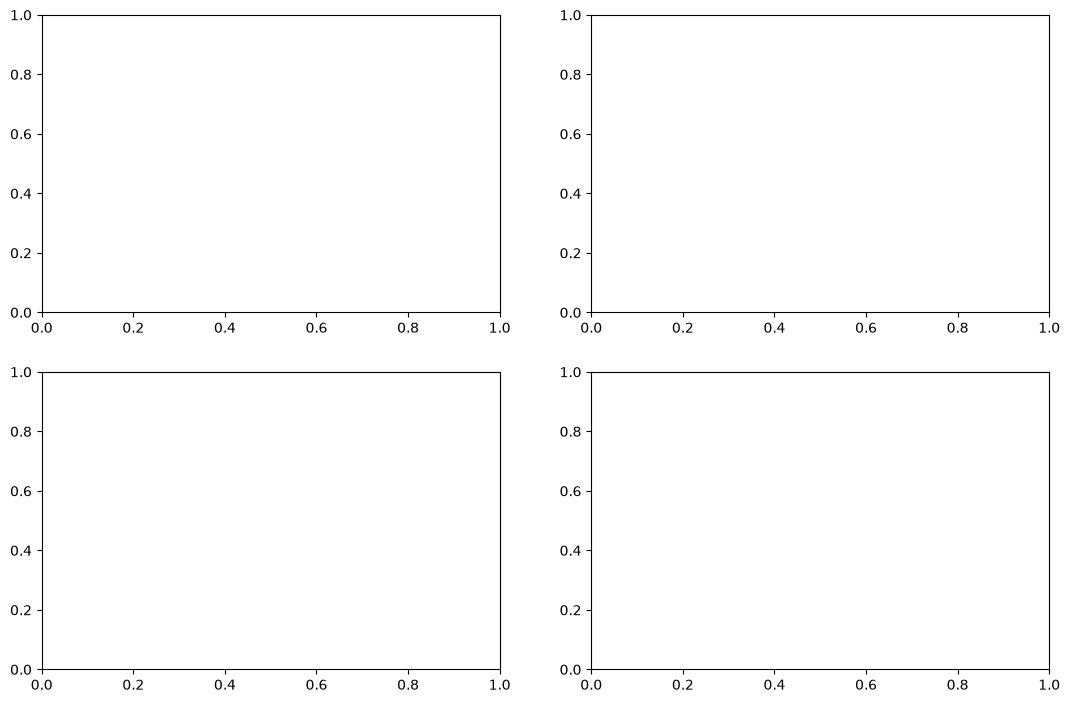

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

for r in fusion_results:
    epochs = [e["epoch"] for e in r["history"]]
    axes[0, 0].plot(epochs, [e["train_loss"] for e in r["history"]], label=f"seed {r['seed']}")
    axes[0, 1].plot(epochs, [e["train_f1"] for e in r["history"]], linestyle="--", alpha=0.5)
    axes[0, 1].plot(epochs, [e["val_f1"] for e in r["history"]], label=f"seed {r['seed']} (val)")
    axes[1, 0].plot(epochs, [e["val_auc"] for e in r["history"]], label=f"seed {r['seed']}")

for ax, title, ylabel in [(axes[0, 0], "Train loss", "loss"),
                          (axes[0, 1], "Train F1 (dashed) vs. val F1 (solid)", "F1"),
                          (axes[1, 0], "Val AUC", "AUC")]:
    for x, ls, lbl in [(6, "--", "unfreeze last-1"), (8, ":", "unfreeze last-2"), (12, "-.", "unfreeze full")]:
        ax.axvline(x, color="gray", linestyle=ls, linewidth=0.8, label=lbl)
    ax.set_xlabel("epoch"); ax.set_ylabel(ylabel); ax.set_title(f"{title} (per seed)")
    ax.legend(fontsize=6)

if fusion_results:
    epochs = [e["epoch"] for e in fusion_results[0]["history"]]
    cls_by_epoch = np.array([[e["cls_loss"] for e in r["history"]] for r in fusion_results])
    reg_by_epoch = np.array([[e["reg_loss"] for e in r["history"]] for r in fusion_results])
    recon_by_epoch = np.array([[e["recon_loss"] for e in r["history"]] for r in fusion_results])
    axes[1, 1].plot(epochs, cls_by_epoch.mean(axis=0), label="cls_loss", color="#4C72B0")
    axes[1, 1].plot(epochs, reg_by_epoch.mean(axis=0), label="reg_loss", color="#DD8452")
    axes[1, 1].plot(epochs, recon_by_epoch.mean(axis=0), label="recon_loss", color="#55A868")
    axes[1, 1].set_xlabel("epoch"); axes[1, 1].set_ylabel("loss component")
    axes[1, 1].set_title("Task-loss components (mean across seeds, train)")
    axes[1, 1].legend(fontsize=8)

plt.suptitle(f"Training Curves -- {MODEL_LABEL}")
plt.tight_layout()
plt.show()


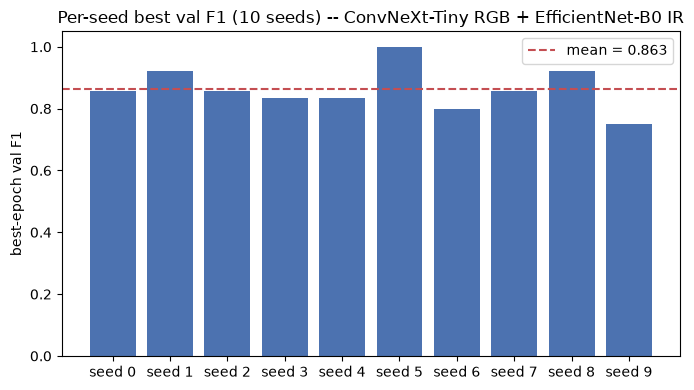

In [33]:
if fusion_results:
    f1s = [r["val_f1"] for r in fusion_results]
    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(len(f1s))
    ax.bar(x, f1s, color="#4C72B0")
    mean_f1 = np.mean(f1s)
    ax.axhline(mean_f1, color="#C44E52", linestyle="--", label=f"mean = {mean_f1:.3f}")
    ax.set_xticks(x); ax.set_xticklabels([f"seed {r['seed']}" for r in fusion_results])
    ax.set_ylabel("best-epoch val F1"); ax.set_title(f"Per-seed best val F1 ({len(f1s)} seeds) -- {MODEL_LABEL}")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 5. Ensemble & k-fold threshold calibration

In [34]:
def collect_group_probs_test_only(run_key, seeds, out_dir, loader_calib, loader_test):
    calib_probs, test_probs, calib_f1_per_seed, seeds_loaded = [], [], [], []
    calib_labels = test_labels = None
    for seed in seeds:
        state_path = out_dir / run_key / f"seed_{seed}" / "model_state.pt"
        if not state_path.exists():
            print(f"  [skip] no checkpoint for {run_key} seed={seed}")
            continue
        model = TrimodalFusionModel(
            rgb_backbone_name=RGB_BACKBONE_NAME, ir_backbone_name=IR_BACKBONE_NAME,
            d_model=D_MODEL, dropout=DROPOUT, cls_dropout=DROPOUT, freeze_visual_backbone=True,
        ).to(cfg["device"])
        model.load_state_dict(torch.load(state_path, map_location=cfg["device"]))
        uncertainty_loss = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])
        c_p, c_l, _, _ = collect_probs_labels(model, uncertainty_loss, loader_calib, cfg)
        t_p, t_l, _, _ = collect_probs_labels(model, uncertainty_loss, loader_test, cfg)
        thr, _ = calibrate_threshold(c_p[:, 1].tolist(), c_l)
        seed_f1 = f1_score(c_l, (c_p[:, 1] >= thr).astype(int).tolist(), average="binary", zero_division=0)
        calib_probs.append(c_p); test_probs.append(t_p)
        calib_f1_per_seed.append(seed_f1); seeds_loaded.append(seed)
        calib_labels, test_labels = c_l, t_l
    return {"calib_probs": calib_probs, "test_probs": test_probs, "calib_labels": calib_labels,
            "test_labels": test_labels, "calib_f1_per_seed": calib_f1_per_seed, "seeds_loaded": seeds_loaded}


def kfold_calibrate_and_evaluate(model_label, group, baseline_f1=0.7692):
    n = len(group["seeds_loaded"])
    if n == 0:
        print(f"  [{model_label}] no seeds loaded -- nothing to evaluate.")
        return None

    w = np.ones(n) / n
    avg_calib = np.tensordot(w, np.stack(group["calib_probs"]), axes=1)
    avg_test = np.tensordot(w, np.stack(group["test_probs"]), axes=1)

    calib_labels_arr = np.array(group["calib_labels"])
    min_class_count = min((calib_labels_arr == 0).sum(), (calib_labels_arr == 1).sum())
    K = max(2, min(6, int(min_class_count)))

    print(f"[{model_label}] calib (train+val) label counts: "
          f"not_spoiled={int((calib_labels_arr == 0).sum())}, spoiled={int((calib_labels_arr == 1).sum())} "
          f"-> K={K} folds")

    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=0)
    fold_thresholds, fold_f1s = [], []
    print(f"{'fold':<6}{'fold n':<9}{'threshold':<12}{'held-out F1 at that threshold':<32}")
    print("-" * 60)
    for fold_idx, (fold_train_idx, fold_heldout_idx) in enumerate(skf.split(avg_calib, calib_labels_arr)):
        fold_scores = avg_calib[fold_train_idx, 1].tolist()
        fold_labels = calib_labels_arr[fold_train_idx].tolist()
        thr, _ = calibrate_threshold(fold_scores, fold_labels)

        heldout_scores = avg_calib[fold_heldout_idx, 1]
        heldout_labels = calib_labels_arr[fold_heldout_idx]
        heldout_preds = (heldout_scores >= thr).astype(int)
        heldout_f1 = f1_score(heldout_labels, heldout_preds, average="binary", zero_division=0)

        fold_thresholds.append(thr)
        fold_f1s.append(heldout_f1)
        print(f"{fold_idx:<6}{len(fold_train_idx):<9}{thr:<12.3f}{heldout_f1:<32.4f}")

    naive_threshold, _ = calibrate_threshold(avg_calib[:, 1].tolist(), group["calib_labels"])
    robust_threshold = float(np.median(fold_thresholds))
    threshold_spread = max(fold_thresholds) - min(fold_thresholds)

    print()
    print(f"Per-fold thresholds: {[round(t, 3) for t in fold_thresholds]}")
    print(f"  spread (max-min): {threshold_spread:.3f}  |  median (robust): {robust_threshold:.3f}  "
          f"|  mean: {np.mean(fold_thresholds):.3f}")
    print(f"  naive single-threshold: {naive_threshold:.3f}  |  difference vs robust: "
          f"{robust_threshold - naive_threshold:+.3f}")

    test_preds_robust = (avg_test[:, 1] >= robust_threshold).astype(int).tolist()
    test_f1 = f1_score(group["test_labels"], test_preds_robust, average="binary", zero_division=0)
    try:
        test_auc = roc_auc_score(group["test_labels"], avg_test[:, 1])
    except ValueError:
        test_auc = float("nan")
    test_preds_naive = (avg_test[:, 1] >= naive_threshold).astype(int).tolist()
    naive_test_f1 = f1_score(group["test_labels"], test_preds_naive, average="binary", zero_division=0)

    print()
    print("=" * 90)
    print(f"{model_label} - TEST EVALUATION")
    print("=" * 90)
    print(f"  Ensemble:  {n} seeds, unweighted average")
    print(f"  Threshold: {robust_threshold:.3f} (k-fold median, K={K}, spread={threshold_spread:.3f})")
    print(f"  TEST F1  = {test_f1:.4f}")
    print(f"  TEST AUC = {test_auc:.4f}")

    return {"n_seeds": n, "K": K, "fold_thresholds": fold_thresholds, "robust_threshold": robust_threshold,
            "naive_threshold": naive_threshold, "threshold_spread": threshold_spread,
            "test_f1": round(float(test_f1), 4), "test_auc": round(float(test_auc), 4),
            "test_preds": test_preds_robust, "test_probs_pos": avg_test[:, 1].tolist(),
            "test_labels": group["test_labels"], "calib_probs_pos": avg_calib[:, 1].tolist(),
            "calib_labels": group["calib_labels"]}


In [35]:
group = collect_group_probs_test_only(RUN_KEY, SEEDS, FUSION_OUT, trainval_loader_calib, test_loader)
result = kfold_calibrate_and_evaluate(MODEL_LABEL, group)

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_23665/1486618883.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_23665/1486618883.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_23665/1486618883.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_23665/1486618883.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_lay

[ConvNeXt-Tiny RGB + EfficientNet-B0 IR] calib (train+val) label counts: not_spoiled=12, spoiled=12 -> K=6 folds
fold  fold n   threshold   held-out F1 at that threshold   
------------------------------------------------------------
0     20       0.660       0.8000                          
1     20       0.660       1.0000                          
2     20       0.650       0.8000                          
3     20       0.660       1.0000                          
4     20       0.680       0.6667                          
5     20       0.660       1.0000                          

Per-fold thresholds: [0.66, 0.66, 0.65, 0.66, 0.68, 0.66]
  spread (max-min): 0.030  |  median (robust): 0.660  |  mean: 0.662
  naive single-threshold: 0.660  |  difference vs robust: +0.000

ConvNeXt-Tiny RGB + EfficientNet-B0 IR - TEST EVALUATION
  Ensemble:  10 seeds, unweighted average
  Threshold: 0.660 (k-fold median, K=6, spread=0.030)
  TEST F1  = 0.7143
  TEST AUC = 0.7000


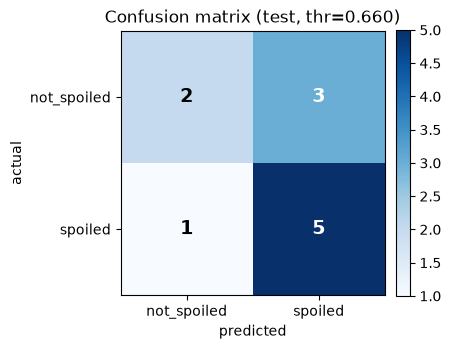

In [36]:
if result:
    cm = confusion_matrix(result["test_labels"], result["test_preds"], labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["not_spoiled", "spoiled"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["not_spoiled", "spoiled"])
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
    ax.set_title(f"Confusion matrix (test, thr={result['robust_threshold']:.3f})")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14, fontweight="bold")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


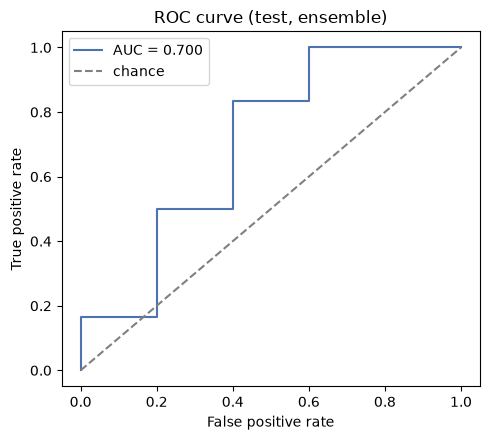

In [37]:
if result:
    fpr, tpr, _ = roc_curve(result["test_labels"], result["test_probs_pos"])
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(fpr, tpr, color="#4C72B0", label=f"AUC = {result['test_auc']:.3f}")
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="chance")
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title("ROC curve (test, ensemble)")
    ax.legend()
    plt.tight_layout()
    plt.show()


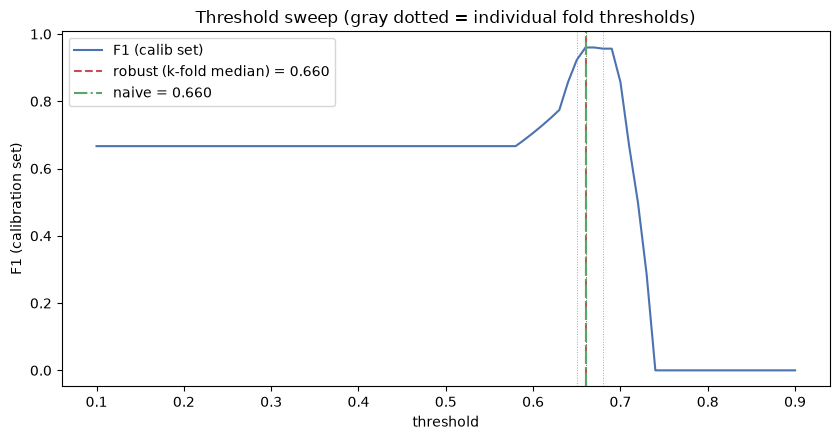

In [38]:
if result:
    f1_by_threshold = []
    for t in THRESHOLDS_TO_SWEEP:
        preds = [1 if s >= t else 0 for s in result["calib_probs_pos"]]
        f1_by_threshold.append(f1_score(result["calib_labels"], preds, average="binary", zero_division=0))

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.plot(THRESHOLDS_TO_SWEEP, f1_by_threshold, color="#4C72B0", label="F1 (calib set)")
    for t in result["fold_thresholds"]:
        ax.axvline(t, color="gray", linestyle=":", linewidth=0.7, alpha=0.7)
    ax.axvline(result["robust_threshold"], color="#C44E52", linestyle="--",
               label=f"robust (k-fold median) = {result['robust_threshold']:.3f}")
    ax.axvline(result["naive_threshold"], color="#55A868", linestyle="-.",
               label=f"naive = {result['naive_threshold']:.3f}")
    ax.set_xlabel("threshold"); ax.set_ylabel("F1 (calibration set)")
    ax.set_title("Threshold sweep (gray dotted = individual fold thresholds)")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [2]:
def collect_group_probs_test_only(run_key, seeds, out_dir, loader_calib, loader_test):
    calib_probs, test_probs, calib_f1_per_seed, seeds_loaded = [], [], [], []
    calib_days_pred, test_days_pred = [], []
    calib_labels = test_labels = calib_days_gt = test_days_gt = None
    for seed in seeds:
        state_path = out_dir / run_key / f"seed_{seed}" / "model_state.pt"
        if not state_path.exists():
            print(f"  [skip] no checkpoint for {run_key} seed={seed}")
            continue
        model = TrimodalFusionModel(
            rgb_backbone_name=RGB_BACKBONE_NAME, ir_backbone_name=IR_BACKBONE_NAME,
            d_model=D_MODEL, dropout=DROPOUT, cls_dropout=DROPOUT, freeze_visual_backbone=True,
        ).to(cfg["device"])
        model.load_state_dict(torch.load(state_path, map_location=cfg["device"]))
        uncertainty_loss = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])
        c_p, c_l, c_dg, c_dp = collect_probs_labels(model, uncertainty_loss, loader_calib, cfg)
        t_p, t_l, t_dg, t_dp = collect_probs_labels(model, uncertainty_loss, loader_test, cfg)
        thr, _ = calibrate_threshold(c_p[:, 1].tolist(), c_l)
        seed_f1 = f1_score(c_l, (c_p[:, 1] >= thr).astype(int).tolist(), average="binary", zero_division=0)
        calib_probs.append(c_p); test_probs.append(t_p)
        calib_days_pred.append(c_dp); test_days_pred.append(t_dp)
        calib_f1_per_seed.append(seed_f1); seeds_loaded.append(seed)
        calib_labels, test_labels = c_l, t_l
        calib_days_gt, test_days_gt = c_dg, t_dg
    return {"calib_probs": calib_probs, "test_probs": test_probs, "calib_labels": calib_labels,
            "test_labels": test_labels, "calib_f1_per_seed": calib_f1_per_seed, "seeds_loaded": seeds_loaded,
            "calib_days_pred": calib_days_pred, "test_days_pred": test_days_pred,
            "calib_days_gt": calib_days_gt, "test_days_gt": test_days_gt}


def kfold_calibrate_and_evaluate(model_label, group, baseline_f1=0.7692):
    n = len(group["seeds_loaded"])
    if n == 0:
        print(f"  [{model_label}] no seeds loaded -- nothing to evaluate.")
        return None

    w = np.ones(n) / n
    avg_calib = np.tensordot(w, np.stack(group["calib_probs"]), axes=1)
    avg_test = np.tensordot(w, np.stack(group["test_probs"]), axes=1)
    avg_test_days_pred = np.tensordot(w, np.stack(group["test_days_pred"]), axes=1)

    calib_labels_arr = np.array(group["calib_labels"])
    min_class_count = min((calib_labels_arr == 0).sum(), (calib_labels_arr == 1).sum())
    K = max(2, min(6, int(min_class_count)))

    print(f"[{model_label}] calib (train+val) label counts: "
          f"not_spoiled={int((calib_labels_arr == 0).sum())}, spoiled={int((calib_labels_arr == 1).sum())} "
          f"-> K={K} folds")

    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=0)
    fold_thresholds, fold_f1s = [], []
    print(f"{'fold':<6}{'fold n':<9}{'threshold':<12}{'held-out F1 at that threshold':<32}")
    print("-" * 60)
    for fold_idx, (fold_train_idx, fold_heldout_idx) in enumerate(skf.split(avg_calib, calib_labels_arr)):
        fold_scores = avg_calib[fold_train_idx, 1].tolist()
        fold_labels = calib_labels_arr[fold_train_idx].tolist()
        thr, _ = calibrate_threshold(fold_scores, fold_labels)

        heldout_scores = avg_calib[fold_heldout_idx, 1]
        heldout_labels = calib_labels_arr[fold_heldout_idx]
        heldout_preds = (heldout_scores >= thr).astype(int)
        heldout_f1 = f1_score(heldout_labels, heldout_preds, average="binary", zero_division=0)

        fold_thresholds.append(thr)
        fold_f1s.append(heldout_f1)
        print(f"{fold_idx:<6}{len(fold_train_idx):<9}{thr:<12.3f}{heldout_f1:<32.4f}")

    naive_threshold, _ = calibrate_threshold(avg_calib[:, 1].tolist(), group["calib_labels"])
    robust_threshold = float(np.median(fold_thresholds))
    threshold_spread = max(fold_thresholds) - min(fold_thresholds)

    print()
    print(f"Per-fold thresholds: {[round(t, 3) for t in fold_thresholds]}")
    print(f"  spread (max-min): {threshold_spread:.3f}  |  median (robust): {robust_threshold:.3f}  "
          f"|  mean: {np.mean(fold_thresholds):.3f}")
    print(f"  naive single-threshold: {naive_threshold:.3f}  |  difference vs robust: "
          f"{robust_threshold - naive_threshold:+.3f}")

    test_preds_robust = (avg_test[:, 1] >= robust_threshold).astype(int).tolist()
    test_f1 = f1_score(group["test_labels"], test_preds_robust, average="binary", zero_division=0)
    try:
        test_auc = roc_auc_score(group["test_labels"], avg_test[:, 1])
    except ValueError:
        test_auc = float("nan")
    test_preds_naive = (avg_test[:, 1] >= naive_threshold).astype(int).tolist()
    naive_test_f1 = f1_score(group["test_labels"], test_preds_naive, average="binary", zero_division=0)

    test_mae = mean_absolute_error(group["test_days_gt"], avg_test_days_pred)
    test_rmse = mean_squared_error(group["test_days_gt"], avg_test_days_pred) ** 0.5
    test_r2 = r2_score(group["test_days_gt"], avg_test_days_pred)

    print()
    print("=" * 90)
    print(f"{model_label} - TEST EVALUATION")
    print("=" * 90)
    print(f"  Ensemble:  {n} seeds, unweighted average")
    print(f"  Threshold: {robust_threshold:.3f} (k-fold median, K={K}, spread={threshold_spread:.3f})")
    print(f"  TEST F1   = {test_f1:.4f}")
    print(f"  TEST AUC  = {test_auc:.4f}")
    print(f"  TEST MAE  = {test_mae:.4f}")
    print(f"  TEST RMSE = {test_rmse:.4f}")
    print(f"  TEST R2   = {test_r2:.4f}")

    return {"n_seeds": n, "K": K, "fold_thresholds": fold_thresholds, "robust_threshold": robust_threshold,
            "naive_threshold": naive_threshold, "threshold_spread": threshold_spread,
            "test_f1": round(float(test_f1), 4), "test_auc": round(float(test_auc), 4),
            "test_mae": round(float(test_mae), 4), "test_rmse": round(float(test_rmse), 4),
            "test_r2": round(float(test_r2), 4),
            "test_preds": test_preds_robust, "test_probs_pos": avg_test[:, 1].tolist(),
            "test_labels": group["test_labels"], "calib_probs_pos": avg_calib[:, 1].tolist(),
            "calib_labels": group["calib_labels"]}